In this notebook, I will provide an overview of the dataset, perform cleaning and formatting based on the assumption checks conducted in 02_assumptions.ipynb, and saving it into a parquet format prior to performing the exploratory data analysis (EDA).

In [ ]:
import pandas as pd
import os
import seaborn as sns 
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [ ]:
df_raw = pd.read_csv("../data/raw/ncr_ride_bookings.csv")


In [ ]:
df_raw.head()

In [ ]:
df_raw.info(memory_usage = "deep")

I have a list of to-do's from the previous notebook:
 
1. Convert names into snake case
2. Map target variable 
3. Remove data leakage
4. Format Booking ID and Customer ID
5. Recast columns 


## Convert names into snake case

In [ ]:
import re 
df_columns_clean = df_raw.copy()
def to_snake_case(df):
    new_columns = []
    for col in df.columns:
        col = col.strip()
        col = re.sub(r'[\s\-]+', '_', col)
        col = re.sub(r'[^\w_]', '', col)
        col = col.lower()
        new_columns.append(col)
    
    df.columns = new_columns
    return df

df_columns_clean = to_snake_case(df_columns_clean)
print(df_columns_clean.columns.tolist())

## Map target variable

In [ ]:
df_target_mapped = df_columns_clean.copy()

booking_mapping = {
    "Completed": 0,
    "Cancelled by Driver": 1,
    "No Driver Found": 1,
    "Cancelled by Customer": 1,
    "Incomplete": 0
}

df_target_mapped['is_cancelled'] = df_target_mapped['booking_status'].map(booking_mapping)
del df_target_mapped["booking_status"]
df_target_mapped['is_cancelled'].value_counts()

## Remove data leakage

Leaking columns: 
- Cancelled Rides by Driver
- Cancelled Rides by Customer
- Reason for cancelling by Customer
- Driver Cancellation Reason
- Incomplete Rides
- Incomplete Rides Reason
- Driver Ratings
- Customer Rating

In [ ]:
df_leak_clean = df_target_mapped.copy()

df_leak_clean.drop(columns = ["cancelled_rides_by_customer",
                                "reason_for_cancelling_by_customer",
                                "cancelled_rides_by_driver",
                                "driver_cancellation_reason",
                                "incomplete_rides",
                                "incomplete_rides_reason",
                                "driver_ratings",
                                "customer_rating"], inplace = True)

df_leak_clean.shape[0], df_leak_clean.shape[1]

## Format Booking ID and Customer ID

In [ ]:
df_clean_quotes = df_leak_clean.copy()

cols_with_quotes = ["booking_id", 
                    "customer_id"]

for col in cols_with_quotes:
    df_clean_quotes[col] = df_clean_quotes[col].str.strip('"')

df_clean_quotes[["booking_id", 
                    "customer_id"]]

## Recast columns

In [ ]:
df_typed = df_clean_quotes.copy()

df_typed.info()

### Temporal features

Converting column `date` and `time` would add unnecessary complexity so I will merge them into datetime later. 

### Categorical
1. Columns with "object" data type and no nulls are directly turned into Category
   
2. Columns with "object" data type and nulls are turned into Category based on threshold. Threshold is set to 0.5, that means less than 50% of values are unique. If threshold is less that this value, the column will be turned into string[pyarrow] type. 

In [ ]:
cat_ambiguous = ["booking_id", 
               "customer_id" ]
cat_threshold = 0.5

for col in cat_ambiguous:
    if col in df_typed.columns:
        num_unique = df_typed[col].nunique(dropna = False)
        ratio_unique = num_unique/len(df_typed)

        if ratio_unique <= cat_threshold:
            df_typed[col] = df_typed[col].astype("category")
            print(f"- Column {col} has been transformed into Category")
            print(f"Ratio of the column: {ratio_unique:.4%}")
        else:
            df_typed[col] = df_typed[col].astype("string[pyarrow]")
            print(f"- Column {col} has been transformed into string[pyarrow]")
            print(f"Ratio of the column: {ratio_unique:.4%}")


In [ ]:
cat_columns = ["vehicle_type", 
               "pickup_location", 
               "drop_location",
               "payment_method"]

for col in cat_columns:
    if col in df_typed.columns:
        df_typed[col] = df_typed[col].astype("category")
        print(f"- Column {col} has been transformed into Category")

### Numerical

i usually perform type optimization since I'm working on my personal computer. In this case, since the dataset is not very big, I will only transform the numerical data into float32

In [ ]:
numerical_columns = ["avg_vtat", 
                 "avg_ctat", 
                 "booking_value",
                 "ride_distance",
                 "is_cancelled"]

for col in numerical_columns:
    if col in df_typed.columns:
        df_typed[col] = df_typed[col].astype("float32")
        print(f"- Column {col} has been transformed into float32")


In [ ]:
df_typed.to_parquet("../data/bronze/clean_dataset.parquet",  engine='fastparquet', index=False)

## Data Profiling

In [2]:
import pandas as pd
import os 
import seaborn as sns 
import matplotlib.pyplot as plt

df_typed = pd.read_parquet("../data/bronze/clean_dataset.parquet",  engine='fastparquet', index=False)
df_typed

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
0,2024-03-23,12:29:38,CNR5884300,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,1.0
1,2024-11-29,18:01:39,CNR1326809,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.000000,237.0,5.730000,UPI,0.0
2,2024-08-23,08:56:10,CNR8494506,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.799999,627.0,13.580000,Debit Card,0.0
3,2024-10-21,17:17:25,CNR8906825,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.500000,416.0,34.020000,UPI,0.0
4,2024-09-16,22:08:00,CNR1950162,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.600000,737.0,48.209999,UPI,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,CNR6500631,CID4337371,Go Mini,MG Road,Ghitorni,10.2,44.400002,475.0,40.080002,Uber Wallet,0.0
149996,2024-11-24,15:55:09,CNR2468611,CID2325623,Go Mini,Golf Course Road,Akshardham,5.1,30.799999,1093.0,21.309999,UPI,0.0
149997,2024-09-18,10:55:15,CNR6358306,CID9925486,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.400000,852.0,15.930000,Cash,0.0
149998,2024-10-05,07:53:34,CNR3030099,CID9415487,Auto,Ghaziabad,Saidulajab,6.9,39.599998,333.0,45.540001,UPI,0.0


In [3]:
data = df_typed.copy()
data = data.sort_values(["date", "time"]).reset_index(drop=True)

In [4]:
data.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.900002,99.0,37.980000,Cash,0.0
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.100000,114.0,39.290001,Uber Wallet,0.0
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,NaN,1.0
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,NaN,1.0
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,NaN,1.0


In [5]:
data.tail()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
149995,2024-12-30,22:58:00,CNR9030698,CID6939658,Bike,DLF Phase 3,Okhla,6.9,35.799999,440.0,12.850000,UPI,0.0
149996,2024-12-30,23:03:14,CNR1507833,CID9905090,eBike,Saket,Noida Sector 62,7.9,33.599998,279.0,39.360001,UPI,0.0
149997,2024-12-30,23:17:05,CNR2265113,CID4170406,Go Mini,GTB Nagar,Anand Vihar ISBT,9.9,39.900002,1855.0,38.910000,UPI,0.0
149998,2024-12-30,23:21:12,CNR4066733,CID8938559,Uber XL,Ashram,Vasant Kunj,2.6,26.700001,520.0,36.369999,Uber Wallet,0.0
149999,2024-12-30,23:36:11,CNR6915581,CID5185745,Auto,Pitampura,Nehru Place,3.5,11.900000,571.0,2.670000,UPI,0.0


In [6]:
import numpy as np

stats = data.describe(include='all')
stats.loc['dtype'] = data.dtypes
stats.loc['rows_dataset'] = len(data)

stats.loc['n_missing'] = data.isna().sum()
stats.loc['% missing'] = data.isna().sum() * 100

numeric_cols = data.select_dtypes(include=np.number).columns
if len(numeric_cols) > 0:
    stats.loc['skew', numeric_cols] = data[numeric_cols].skew()
    stats.loc['kurtosis', numeric_cols] = data[numeric_cols].kurtosis()
    stats.loc['range', numeric_cols] = data[numeric_cols].max() - data[numeric_cols].min()
    stats.loc['iqr', numeric_cols] = data[numeric_cols].quantile(0.75) - data[numeric_cols].quantile(0.25)

stats

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
count,150000,150000,150000,150000,150000,150000,150000,139500.0,102000.0,102000.0,102000.0,102000,150000.0
unique,365,62910,148767,148788,7,176,176,NaN,NaN,NaN,NaN,5,NaN
top,2024-11-16,17:44:57,CNR2726142,CID5481002,Auto,Khandsa,Ashram,NaN,NaN,NaN,NaN,UPI,NaN
freq,462,16,3,3,37419,949,936,NaN,NaN,NaN,NaN,45909,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.456351,29.149632,508.295929,24.637012,NaN,0.32
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.773564,8.902577,395.805756,14.002138,NaN,0.466478
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,10.0,50.0,1.0,NaN,0.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.3,21.6,234.0,12.46,NaN,0.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.3,28.799999,414.0,23.719999,NaN,0.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.3,36.799999,689.0,36.82,NaN,1.0


## Univariate Analysis


### date


What is the distribution of the top 20 records per date, and are there any anomalies or patterns in the frequency of dates?


In [7]:
data['date_length'] = data['date'].str.len()
print("\nUnique lengths of date strings:", data['date_length'].unique())
print("Counts per length:")
print(data['date_length'].value_counts())


Unique lengths of date strings: [10]
Counts per length:
date_length
10    150000
Name: count, dtype: int64


In [8]:
date_counts = data['date'].value_counts()
print("\nTop 20 most frequent dates:")
date_counts.head(20)



Top 20 most frequent dates:


date
2024-11-16    462
2024-09-18    456
2024-05-09    456
2024-02-06    452
2024-10-12    452
2024-01-26    452
2024-10-13    451
2024-10-09    451
2024-07-17    451
2024-11-29    450
2024-04-01    449
2024-02-16    449
2024-01-21    449
2024-03-12    448
2024-07-05    446
2024-03-18    446
2024-04-26    446
2024-02-04    446
2024-12-22    446
2024-05-14    445
Name: count, dtype: int64

There is no clear pattern here. Almost every month has a day with a really high amount of bookings

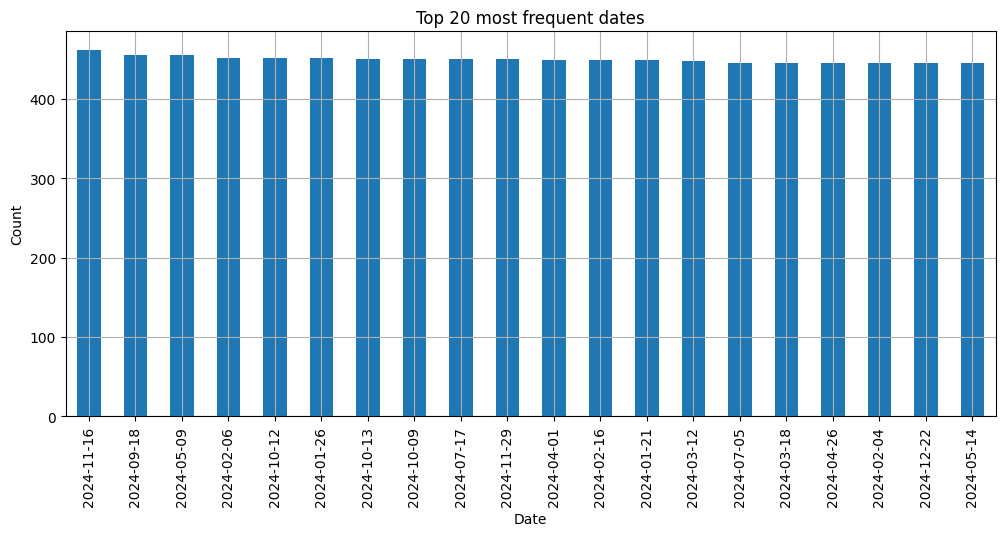

In [9]:
plt.figure(figsize=(12,5))
date_counts.head(20).plot(kind='bar')
plt.title("Top 20 most frequent dates")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid()
plt.show()


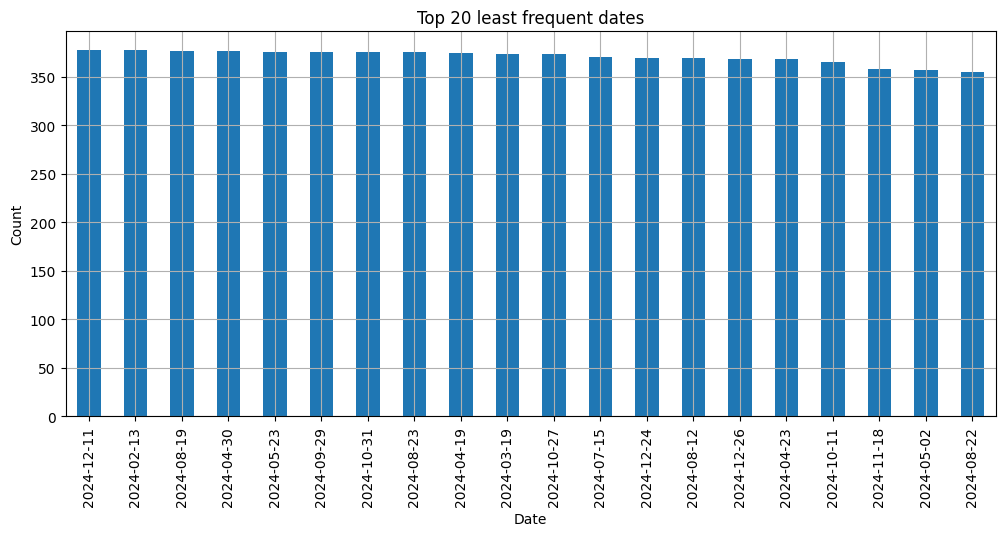

In [10]:
plt.figure(figsize=(12,5))
date_counts.tail(20).plot(kind='bar')
plt.title("Top 20 least frequent dates")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid()
plt.show()


The range bookings in the top 20 days is of 17 bookings. That is interesting. Why is this the maximum number? Was it coincidence? Do we have a bottleneck somewhere? Is it the local record of the city we are analyzing? 

Every day of the year has between 350 and 460 records aprox

It would be interesting to check if those are special days of the year and which is the relationship with cancellations (the amount is the real maximum demand of the service or that flattening is caused by, for example, some service need of improvement)

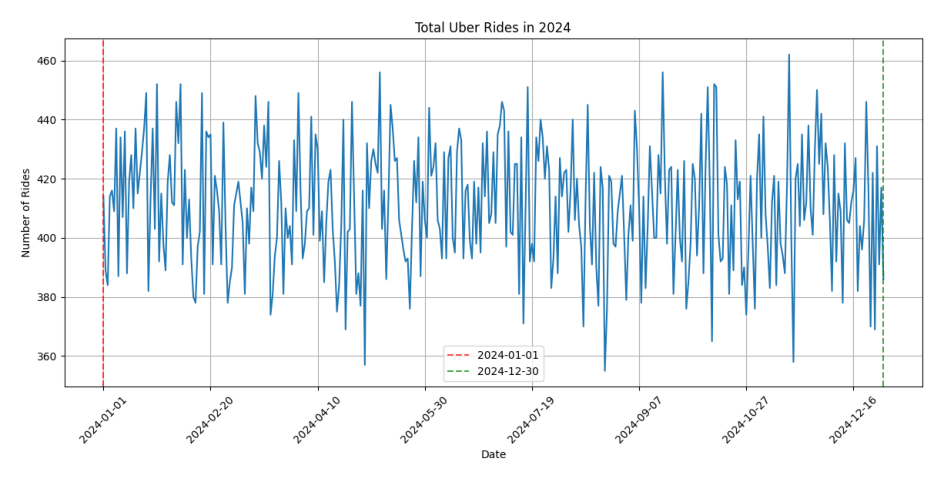

In [11]:
plot_file = 'imgs/date_lineplot.png'

if os.path.exists(plot_file):
    img = plt.imread(plot_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')  
    plt.show()
else:
    plt.figure(figsize=(12, 6))
    daily_counts = data.groupby('date').size()
    plt.plot(daily_counts.index, daily_counts.values)

    first_date = daily_counts.index.min()
    last_date = daily_counts.index.max()
    first_date_label = daily_counts.index.min()
    last_date_label = daily_counts.index.max()
    plt.axvline(first_date, color='red', linestyle='--', alpha=0.7, label=first_date_label)
    plt.axvline(last_date, color='green', linestyle='--', alpha=0.7, label=last_date_label)
    plt.title('Total Uber Rides in 2024')
    plt.xlabel('Date')
    plt.ylabel('Number of Rides')

    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.grid()
    plt.legend()
    plt.tight_layout()
    os.makedirs('imgs', exist_ok=True) 
    plt.savefig(plot_file)
    plt.show()



how can I have 365 unique values if the 31st of Dec does not appear? Maybe there is a 29th of Feb? 

In [12]:
data[data["date"] == "2024-02-29"].head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled,date_length
24403,2024-02-29,00:00:09,CNR2330207,CID8309113,Auto,Kirti Nagar,Sonipat,9.3,NaN,NaN,NaN,NaN,1.0,10
24404,2024-02-29,00:08:57,CNR6004216,CID5184316,Go Mini,Meerut,Ghitorni Village,2.8,21.799999,621.0,6.470000,Credit Card,0.0,10
24405,2024-02-29,00:24:06,CNR1464111,CID1168333,Premier Sedan,Malviya Nagar,Udyog Vihar,3.2,20.200001,444.0,28.160000,Cash,0.0,10
24406,2024-02-29,00:36:19,CNR3852671,CID4695190,Premier Sedan,Malviya Nagar,Connaught Place,NaN,NaN,NaN,NaN,NaN,1.0,10
24407,2024-02-29,01:10:18,CNR9446862,CID3841042,Bike,Okhla,Sarojini Nagar,3.7,25.400000,362.0,37.630001,Credit Card,0.0,10


Ok, it's a leap year



### time

In [13]:
data['time_length'] = data['time'].str.len()
print("\nUnique lengths of time strings:", data['time_length'].unique())
print("Counts per length:")
print(data['time_length'].value_counts())


Unique lengths of time strings: [8]
Counts per length:
time_length
8    150000
Name: count, dtype: int64


In [14]:
time = data['time'].value_counts()
print("\nTop 20 most frequent dates:")
time.head(20)


Top 20 most frequent dates:


time
17:44:57    16
19:17:33    12
17:54:33    11
18:59:55    11
17:55:08    11
11:29:50    11
19:26:48    11
10:23:23    11
15:23:56    11
19:29:07    10
17:38:15    10
18:07:46    10
18:09:57    10
17:34:15    10
18:17:18    10
20:46:08    10
16:16:59    10
19:44:48    10
18:10:37    10
09:45:20    10
Name: count, dtype: int64

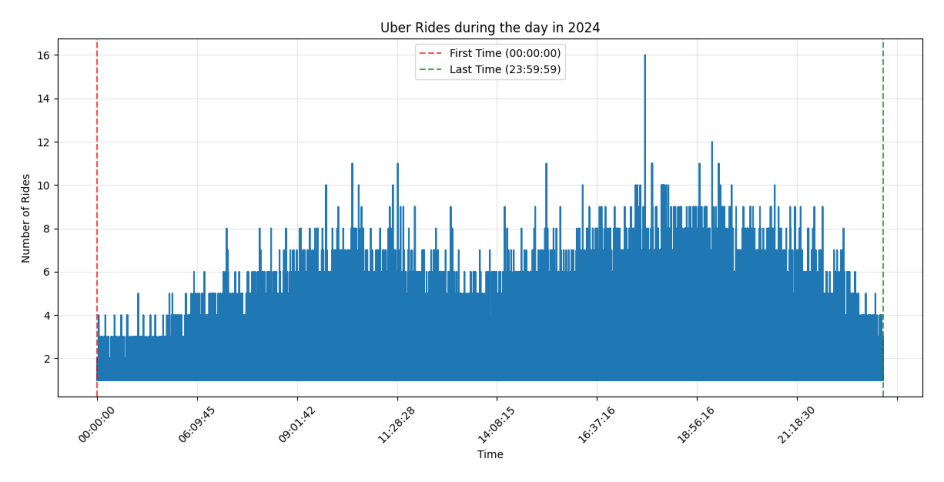

In [15]:
plot_file = 'imgs/time_lineplot.png'

if os.path.exists(plot_file):
    img = plt.imread(plot_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')  
    plt.show()
else:
    plt.figure(figsize=(12, 6))

    time_counts = data.groupby('time').size().sort_index()
    plt.plot(time_counts.index, time_counts.values)

    first_time = time_counts.index.min()
    last_time = time_counts.index.max()
    plt.axvline(first_time, color='red', linestyle='--', alpha=0.7, label=f'First Time ({first_time})')
    plt.axvline(last_time, color='green', linestyle='--', alpha=0.7, label=f'Last Time ({last_time})')

    plt.title('Uber Rides during the day in 2024')
    plt.xlabel('Time')
    plt.ylabel('Number of Rides')

    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    os.makedirs('imgs', exist_ok=True) 
    plt.savefig(plot_file)
    plt.show()


As expected there is so much data because of the seconds that I cannot even see the full lineplot. Let's group by other time units

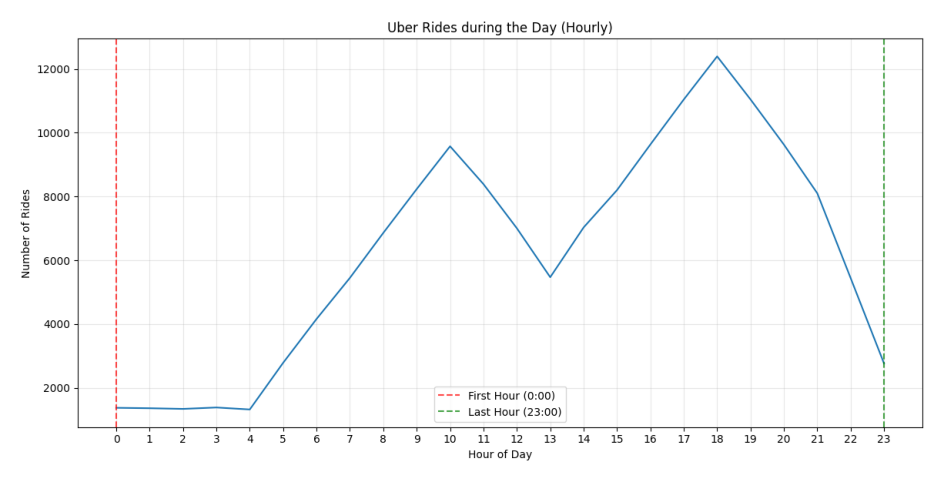

In [16]:
plot_file = 'imgs/time_lineplot_hour.png'

if os.path.exists(plot_file):
    img = plt.imread(plot_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    plt.figure(figsize=(12, 6))
    data['time'] = pd.to_datetime(data['time'])
    time_counts = (
        data
        .groupby(data['time'].dt.hour)
        .size()
        .sort_index()
    )

    plt.plot(time_counts.index, time_counts.values)

    first_time = time_counts.index.min()
    last_time = time_counts.index.max()
    plt.axvline(first_time, color='red', linestyle='--', alpha=0.7, label=f'First Hour ({first_time}:00)')
    plt.axvline(last_time, color='green', linestyle='--', alpha=0.7, label=f'Last Hour ({last_time}:00)')

    plt.title('Uber Rides during the Day (Hourly)')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Rides')

    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    os.makedirs('imgs', exist_ok=True)
    plt.savefig(plot_file)
    plt.show()


The plot shows a clear bimodal daily pattern in Uber ride demand. Activity is minimal during the early morning hours, increases sharply during the morning commute with a peak around 10 AM, dips around midday, and reaches its highest level in the early evening (around 6 PM). Demand then steadily declines toward the end of the day

### new date + time related features

In [42]:
# the 1st of January of 2024 was Monday

data['datetime'] = pd.to_datetime(data['date'] + " " + data['time'], format="%Y-%m-%d %H:%M:%S")

# since there is a clear pattern seen in "time" I create "hour"
data['hour'] = data['datetime'].dt.hour
data['weekday'] = data['datetime'].dt.weekday
data['is_weekend'] = data['weekday'] >= 5

data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)


weekday
0    408.377358
1    411.365385
2    411.788462
3    407.980769
4    411.480769
5    414.269231
6    411.500000
dtype: float64


<Axes: title={'center': 'Average Activity per Weekday (Normalized)'}, xlabel='weekday'>

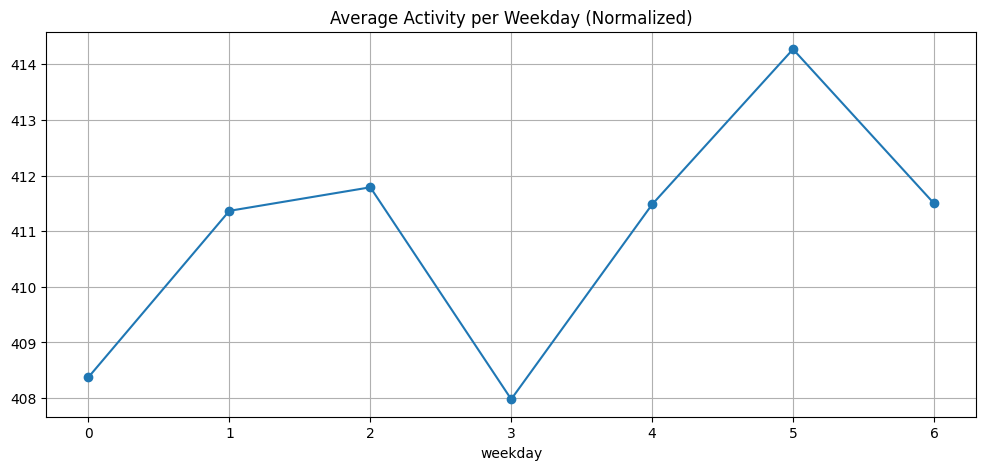

In [36]:
# How is the behaviour of each day?

weekday_counts = data.groupby('weekday').size()

days_per_weekday = data.groupby('weekday')['date'].nunique()
normalized_weekday = weekday_counts / days_per_weekday
print(normalized_weekday)

normalized_weekday.plot(
    kind='line',
    marker='o',
    figsize=(12,5),
    title="Average Activity per Weekday (Normalized)",
    grid=True
)



There is no clear difference between weekdays in this plot; the number of bookings appears to be approximately the same each day 

is_weekend
False    410.191571
True     412.884615
dtype: float64


<Axes: title={'center': 'Average Activity per Day (Weekend vs Weekday)'}, xlabel='is_weekend'>

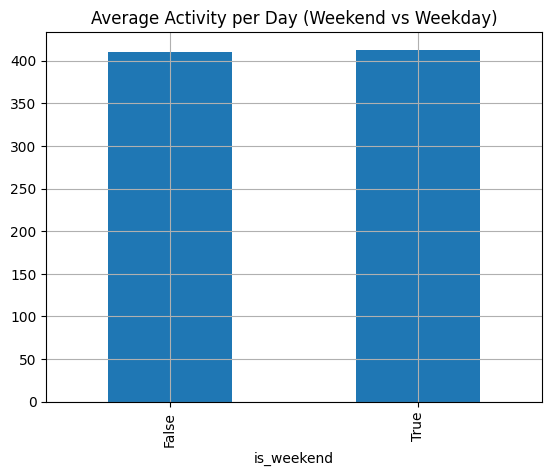

In [35]:
# Is the behaviour changing in the weekend? 

avg_activity = (
    data.groupby('is_weekend')
        .size()
        / data.groupby('is_weekend')['date'].nunique()
)
print(avg_activity)

avg_activity.plot(
    kind='bar',
    title='Average Activity per Day (Weekend vs Weekday)',
    grid=True
)


After normalizing by the number of days, weekend and weekday activity levels are comparable, indicating no strong weekend effect

In [45]:
data[["hour_sin", "hour_cos"]].describe()

,hour_sin,hour_cos
count,150000.000000,150000.000000
mean,-0.242204,-0.212834
std,0.714842,0.620520
min,-1.000000,-1.000000
25%,-0.866025,-0.707107
50%,-0.500000,-0.258819
75%,0.500000,0.258819
max,1.000000,1.000000


Expected: min ≈ -1, max ≈ 1, mean ≈ 0, perfect

To capture the cyclical nature of time, the hour of day was encoded using sine and cosine transformations. This representation preserves the circular structure of time, ensuring that adjacent hours such as 23:00 and 00:00 are represented as similar values.

#### Categorical

In [ ]:
pd.set_option("display.max_rows", None)
cat_cols = df_typed.select_dtypes(include="category").columns


In [ ]:
for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df_typed[col].value_counts(dropna=False))


### String

In [ ]:
string_cols = df_typed.select_dtypes(include="string[pyarrow]").columns


In [ ]:
for col in string_cols:
    print(f"\n=== {col} ===")
    print(df_typed[col].value_counts(dropna=False))

### Numerical

In [ ]:
df_typed.describe()

In [ ]:
df_typed.hist(figsize=(20, 15), bins = 100)

## Train/test split

The dataset goes from the 1st of January 2024 to the 30th December 2024, I will split it following 75% train, 15% val, 10% test.

In [ ]:
df_typed = df_typed.sort_values("date")

train_end = "2024-09-30"  
val_end = "2024-11-30"

train_df = df_typed[df_typed["date"] <= train_end]
val_df   = df_typed[(df_typed["date"] > train_end) & (df_typed["date"] <= val_end)]
test_df  = df_typed[df_typed["date"] > val_end]

In [ ]:
print(f" Train: {len(train_df)}")
print(f" Validation : {len(val_df)}")
print(f" Test: {len(test_df)}")

## Save dataset splits

In [ ]:
output_dir = "../data/bronze"
os.makedirs(output_dir, exist_ok=True)  
df_typed.to_parquet(os.path.join(output_dir, "dataset.parquet"), index=False)
train_df.to_parquet(os.path.join(output_dir, "train.parquet"), index=False)
val_df.to_parquet(os.path.join(output_dir, "val.parquet"), index=False)
test_df.to_parquet(os.path.join(output_dir, "test.parquet"), index=False)